# Multiclass Classification with ml-engine-from-scratch

This notebook demonstrates the use of our from-scratch Deep Learning framework to solve a non-linear multiclass classification problem. 

We will generate a complex synthetic dataset (4 clusters), configure a neural network with our custom `Adam` optimizer, and visualize the decision boundaries learned by the model.

In [49]:
import ml_framework as ml
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import numpy as np

# General configuration
N_SAMPLES = 10000
N_IN_FEATURES = 2
K = 4 # Number of classes (clusters)
RANDOM_SEED = 10
TEST_SIZE = 0.2

rng = np.random.default_rng(RANDOM_SEED)

## 1. Data Generation and Preparation
We use scikit-learn's `make_blobs` to generate 10,000 points distributed across 4 distinct clusters. 

Before passing the data to our neural network, we will plot the raw dataset to understand its geometry. Finally, since our framework uses `CrossEntropyLoss`, we will transform our integer labels (0, 1, 2, 3) into One-Hot Encoded vectors (e.g., `[0, 1, 0, 0]`).

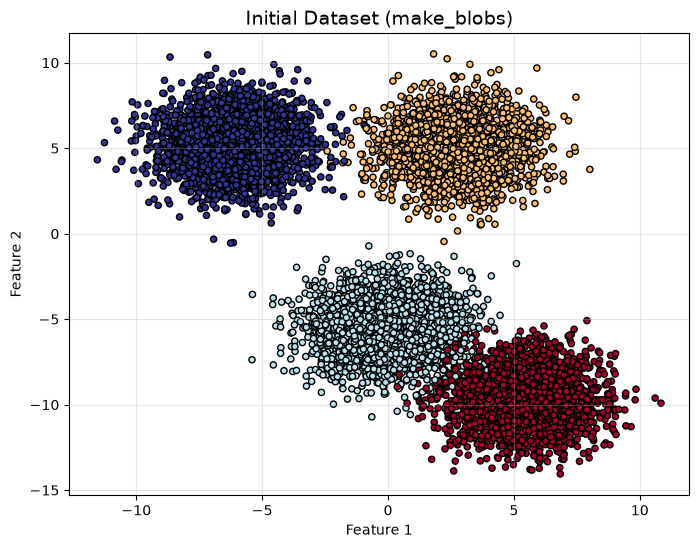

Training data shape: (8000, 2)
Training labels shape (One-Hot): (8000, 4)


In [50]:
def to_one_hot(y: np.ndarray, K: int) -> np.ndarray:
    y_out = np.zeros((len(y), K))
    y_out[np.arange(y.shape[0]), y] = 1
    return y_out

# Data generation
x_data, y_data = make_blobs(n_samples=N_SAMPLES, n_features=N_IN_FEATURES, centers=K, random_state=RANDOM_SEED, cluster_std=1.5)

# Initial Visualization of the Raw Data
plt.figure(figsize=(8, 6))
plt.title("Initial Dataset (make_blobs)", fontsize=14)
plt.scatter(x_data[:, 0], x_data[:, 1], c=y_data, s=20, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=TEST_SIZE, random_state=RANDOM_SEED)

# One-Hot encoding for labels
y_train_one_hot = to_one_hot(y_train, K)
y_test_onehot = to_one_hot(y_test, K)

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape (One-Hot): {y_train_one_hot.shape}")

## 2. Neural Network Architecture
We build a Multi-Layer Perceptron (MLP) with one hidden layers. 

*Engineering Note: For simple datasets like `make_blobs`, non-linear activations aren't strictly necessary since the data is mostly linearly separable (stacking linear layers simply mathematically collapses into a single linear transformation).

In [51]:
hidden_layer_size = 32
LEARNING_RATE = 0.001

# Model creation using our Sequential API
model = ml.Sequential([
    ml.LinearLayer(in_features=N_IN_FEATURES, out_features=hidden_layer_size),
    ml.LinearLayer(in_features=hidden_layer_size, out_features=K) # Output layer
])

# Loss function and Optimizer
loss_fn = ml.CrossEntropyLoss()
optimizer = ml.Adam(learning_rate=LEARNING_RATE)

## 3. Model Training
We train the network for 20 epochs using mini-batches. We record the loss and accuracy history throughout the process to analyze the model's convergence.

In [52]:
EPOCHS = 20
BATCH_SIZE = 32
TEST_FREQ = 1

train_loss_history, test_loss_history = [], []
train_accuracy_history, test_accuracy_history = [], []

for epoch in range(EPOCHS):
    model.train()
    
    # Shuffle training data
    indices = np.arange(0, len(X_train))
    rng.shuffle(indices)

    avg_train_loss = 0
    avg_train_accuracy = 0
    
    # Mini-batch loop
    for start_idx in np.arange(0, len(X_train), BATCH_SIZE):
        end_idx = start_idx + BATCH_SIZE
        X_batch = X_train[indices[start_idx:end_idx]]
        y_batch = y_train_one_hot[indices[start_idx:end_idx]]

        # Forward pass
        batch_logits = model(X_batch)

        # Loss and Accuracy calculation
        avg_train_loss += loss_fn(logits=batch_logits, y_expected=y_batch) * len(y_batch)
        avg_train_accuracy += np.sum(np.argmax(y_batch, axis=1) == np.argmax(batch_logits, axis=1))

        # Backpropagation
        model.backward(loss_fn.backward())

        # Optimizer step
        optimizer.step(model)

    avg_train_accuracy /= len(y_train_one_hot) * 0.01
    avg_train_loss /= len(y_train_one_hot)

    # Evaluation on the test set
    if epoch % TEST_FREQ == 0 or epoch == 0 or epoch == EPOCHS - 1:
        model.eval()
        test_logits = model(X_test)
        test_pred = np.argmax(test_logits, axis=1)
        
        test_loss = loss_fn(logits=test_logits, y_expected=y_test_onehot)
        test_accuracy = np.sum(test_pred == y_test) / len(y_test) * 100

        train_loss_history.append(avg_train_loss)
        train_accuracy_history.append(avg_train_accuracy)
        test_loss_history.append(test_loss)
        test_accuracy_history.append(test_accuracy)

        print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_accuracy:.2f}%")

Epoch 01 | Train Loss: 1.5588 | Train Acc: 75.96% | Test Loss: 0.1132 | Test Acc: 95.95%
Epoch 02 | Train Loss: 0.1117 | Train Acc: 96.04% | Test Loss: 0.0865 | Test Acc: 97.00%
Epoch 03 | Train Loss: 0.0903 | Train Acc: 96.90% | Test Loss: 0.0728 | Test Acc: 97.90%
Epoch 04 | Train Loss: 0.0767 | Train Acc: 97.45% | Test Loss: 0.0616 | Test Acc: 98.30%
Epoch 05 | Train Loss: 0.0649 | Train Acc: 98.09% | Test Loss: 0.0545 | Test Acc: 98.50%
Epoch 06 | Train Loss: 0.0566 | Train Acc: 98.35% | Test Loss: 0.0467 | Test Acc: 98.65%
Epoch 07 | Train Loss: 0.0492 | Train Acc: 98.54% | Test Loss: 0.0416 | Test Acc: 98.75%
Epoch 08 | Train Loss: 0.0436 | Train Acc: 98.80% | Test Loss: 0.0373 | Test Acc: 98.90%
Epoch 09 | Train Loss: 0.0403 | Train Acc: 98.74% | Test Loss: 0.0340 | Test Acc: 99.00%
Epoch 10 | Train Loss: 0.0360 | Train Acc: 99.03% | Test Loss: 0.0393 | Test Acc: 99.10%
Epoch 11 | Train Loss: 0.0328 | Train Acc: 99.15% | Test Loss: 0.0435 | Test Acc: 98.35%
Epoch 12 | Train Loss

## 4. Learning Curves: Loss and Accuracy
Visualizing the training and testing metrics over the epochs helps us ensure the model is converging properly and verify that it isn't overfitting to the training data.

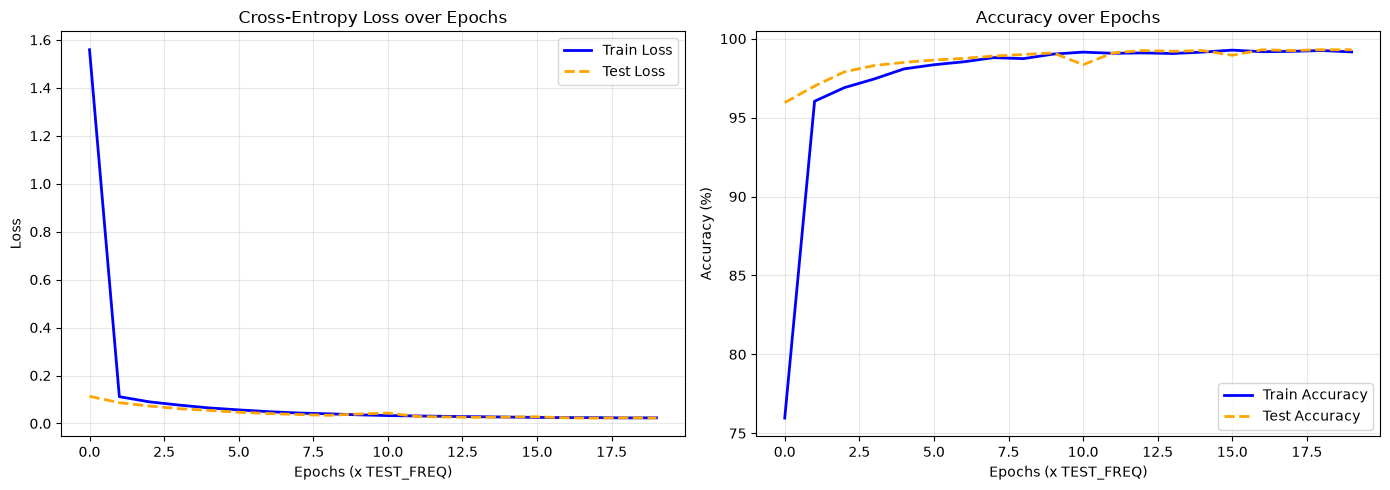

In [53]:
# Create a figure with two side-by-side subplots
plt.figure(figsize=(14, 5))

# Plot 1: Loss over Epochs
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss', color='blue', linewidth=2)
plt.plot(test_loss_history, label='Test Loss', color='orange', linewidth=2, linestyle='--')
plt.title('Cross-Entropy Loss over Epochs', fontsize=12)
plt.xlabel('Epochs (x TEST_FREQ)', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Accuracy over Epochs
plt.subplot(1, 2, 2)
plt.plot(train_accuracy_history, label='Train Accuracy', color='blue', linewidth=2)
plt.plot(test_accuracy_history, label='Test Accuracy', color='orange', linewidth=2, linestyle='--')
plt.title('Accuracy over Epochs', fontsize=12)
plt.xlabel('Epochs (x TEST_FREQ)', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Decision Boundary Visualization
To verify that the network has successfully captured the geometry of the data, we will create a 2D mesh grid, ask the model to predict the class for each point, and plot the resulting decision boundaries.

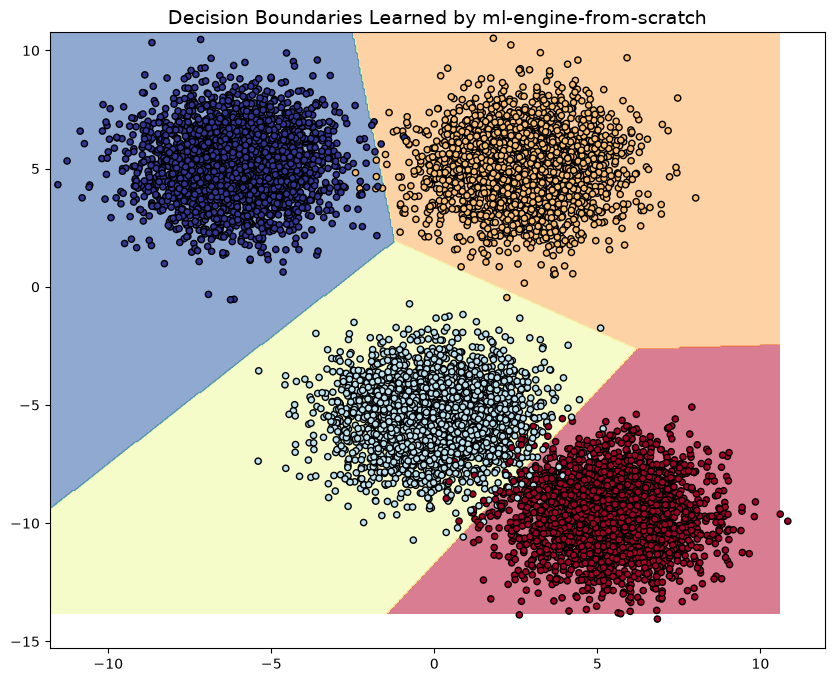

In [54]:
# Create a mesh grid covering the data space
xx, yy = np.meshgrid(
    np.linspace(np.min(x_data[:, 0]) - 0.25, np.max(x_data[:, 0]) - 0.25, 500),
    np.linspace(np.min(x_data[:, 1]) + 0.25, np.max(x_data[:, 1]) + 0.25, 500)
)

# Predict across the entire grid
model.eval()
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_probs = model(grid_points)
grid_preds = np.argmax(grid_probs, axis=1)

# Plotting the boundaries and the original data
plt.figure(figsize=(10, 8))
plt.title("Decision Boundaries Learned by ml-engine-from-scratch", fontsize=14)
plt.contourf(xx, yy, grid_preds.reshape(xx.shape), cmap=plt.cm.Spectral, alpha=0.6)
plt.scatter(x=x_data[:, 0], y=x_data[:, 1], c=y_data, s=20, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.show()

## 6. Conclusion and Engineering Insights

Our custom `ml-engine-from-scratch` framework successfully classified the dataset, achieving an impressive **99.30% test accuracy** in just 20 epochs. The smooth convergence of both the training and testing loss curves demonstrates the stability and mathematical correctness of our custom `Adam` optimizer and `CrossEntropyLoss` implementations.

**Architectural Insight:** 
You will notice that we achieved this >99% accuracy using *only* stacked `LinearLayer`s, completely omitting non-linear activation functions like `ReLU`. Because multiple linear transformations mathematically collapse into a single linear operation, our network effectively acted as a multi-class Softmax Regression model. This exceptional performance confirms that the `make_blobs` dataset is perfectly linearly separable. 

For future experiments with complex, non-linearly separable data (such as the `make_moons` dataset), we can simply inject our `ActivationLayer(ReLU)` between the linear layers to instantly give the network the mathematical flexibility to bend its decision boundaries.